LIBRARIES

In [22]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [23]:
IMG_HEIGHT = 224 #Hyperparameter
IMG_WIDTH = 224  #Hyperparameter
IMG_CHANNELS = 3
CLASS_NAMES = ["lilly", "lotus","orchid", "sunflower","tulip"]

In [24]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,    #Hyperparameter
    image_size = (IMG_HEIGHT, IMG_WIDTH)
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels = 'inferred',
    label_mode= 'int',
    batch_size = 32,     #Hyperparameter
    image_size =(IMG_HEIGHT, IMG_WIDTH)
)

Normalize = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (Normalize(x), y))
val_dataset = val_dataset.map(lambda x, y: (Normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [25]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(128, activation = "relu"),
    keras.layers.Dense(len(CLASS_NAMES), activation = "softmax")
])

model.compile(
    optimizer = "adam", # Hyperparameter learning rate
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy']

)

C:\Users\pmkha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TRAINING

In [26]:
EPOCHS = 10
history =  model.fit(train_dataset, validation_data= val_dataset, epochs = EPOCHS)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.3077 - loss: 33.7045 - val_accuracy: 0.3810 - val_loss: 7.1047
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.3750 - loss: 9.0785 - val_accuracy: 0.3740 - val_loss: 6.2634
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.4210 - loss: 7.5243 - val_accuracy: 0.2580 - val_loss: 15.9825
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.4693 - loss: 6.3862 - val_accuracy: 0.4390 - val_loss: 5.0181
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.4997 - loss: 4.5273 - val_accuracy: 0.2810 - val_loss: 10.3240
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.4573 - loss: 4.9564 - val_accuracy: 0.3380 - val_loss: 5.0524
Epoch 7/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.5710 - loss: 2.0385 - val_accuracy: 0.4710 - val_loss: 2.3110
Epoch 8/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.5453 - loss: 2.5299 - val_accura

PLOTTING

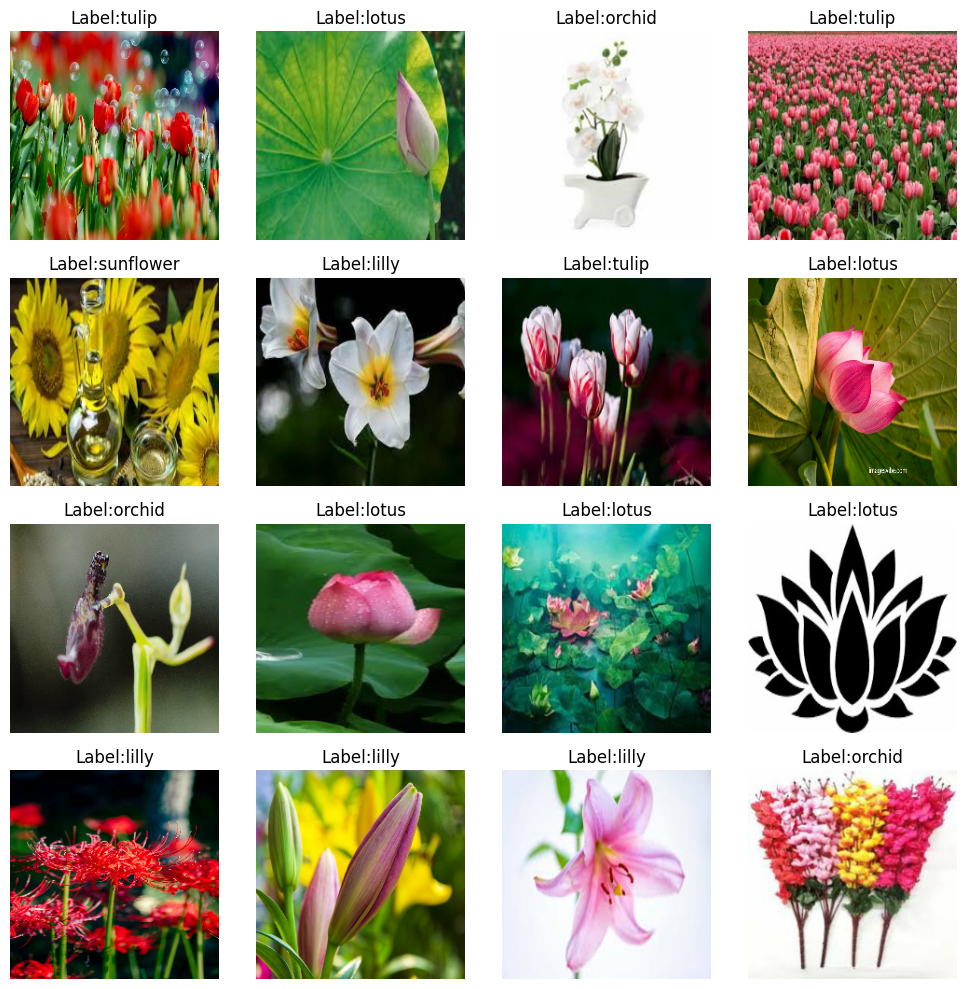

In [27]:
for image, label in train_dataset.take(1):
    fig, axes = plt.subplots(4, 4, figsize = (10,10))

    for i in range(16):
        ax = axes[i//4, i%4]
        ax.imshow(image[i].numpy())
        ax.set_title(f"Label:{CLASS_NAMES[label[i]]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

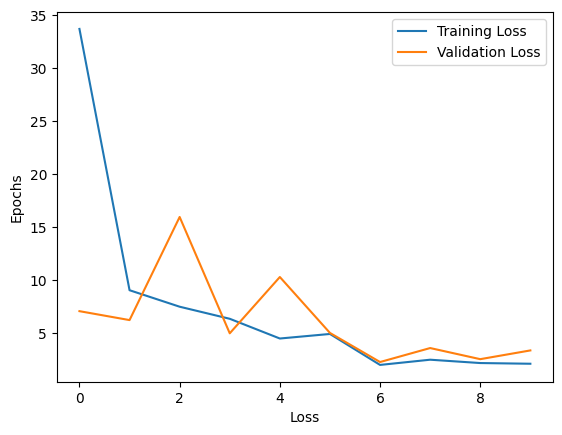

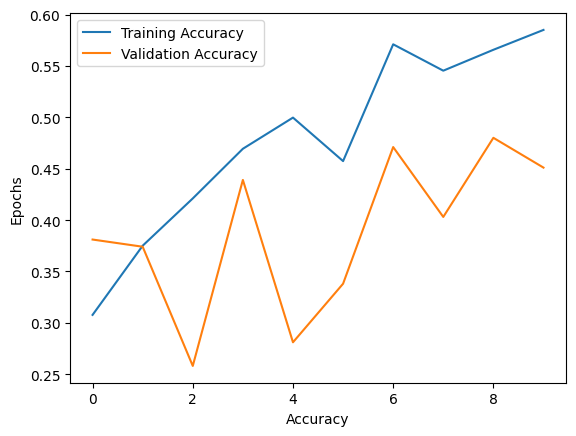

In [28]:
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.xlabel("Loss")
plt.ylabel("Epochs")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")
plt.legend()
plt.show()

# Accuracy for both the linear network and network with activation layer is approximately same
# We can change the below hyperparameters to check for the different loss and accuracy with the change
# Image size to 64x64 or 16x16
# Batch size = 1, 32, 64
# Learning rate = 0.01
# Epochs
# Nodes in hidden layer